In [30]:
import os
import math
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


In [31]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


In [32]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_weights = torch.softmax(scores, dim=-1)

        out = torch.matmul(attn_weights, V)
        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.W_o(out), attn_weights


In [33]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.2):
        super().__init__()

        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.ReLU(),
            nn.Linear(4 * d_model, d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x)
        x = self.norm1(x + self.dropout(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))

        return x, attn_weights


In [34]:
class BatteryTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, num_heads=4, num_layers=3):
        super().__init__()

        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoding = PositionalEncoding(d_model)

        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads)
            for _ in range(num_layers)
        ])

        self.regressor = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)

        all_attn = []

        for layer in self.layers:
            x, attn = layer(x)
            all_attn.append(attn)

        out = self.regressor(x[:, -1, :])
        return out.squeeze(-1), all_attn


In [35]:
class BatteryWindowDataset(Dataset):
    def __init__(
        self,
        csv_files,
        window_size,
        stride,
        feature_cols,
        target_col="SOC",
        ecm_col="SOC_ECM",
        mode_value=-1
    ):
        self.samples = []

        for csv_path in csv_files:
            df = pd.read_csv(csv_path)

            # ECM valid mask
            df["ECM_valid"] = (~df[ecm_col].isna()).astype(int)
            df[ecm_col] = df[ecm_col].fillna(0.0)

            # Mode indicator
            df["mode"] = mode_value

            # Normalize (except masks)
            for col in feature_cols:
                if col not in ["ECM_valid", "mode"]:
                    mean = df[col].mean()
                    std = df[col].std() + 1e-6
                    df[col] = (df[col] - mean) / std

            features = df[feature_cols].values
            soc = df[target_col].values
            soc_ecm = df[ecm_col].values

            for i in range(0, len(df) - window_size, stride):
                x = torch.tensor(
                    features[i:i+window_size], dtype=torch.float32
                )
                y = torch.tensor(
                    soc[i+window_size] - soc_ecm[i+window_size],
                    dtype=torch.float32
                )

                if torch.isnan(x).any() or torch.isnan(y):
                    continue

                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


In [36]:
DATA_DIR = "/Users/lubhanamutha/Desktop/BMS/agentic-ai-battery-health-management-systems/NASA/ECM_processed_cycles"

all_csvs = sorted(
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if f.endswith(".csv")
)


In [37]:
train_csvs, temp_csvs = train_test_split(
    all_csvs, test_size=0.3, random_state=42
)

val_csvs, test_csvs = train_test_split(
    temp_csvs, test_size=0.5, random_state=42
)


In [38]:
feature_cols = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "dV_dt",
    "dT_dt",
    "SOC_ECM",
    "V_RC",
    "V_ECM",
    "mode_flag"
]


In [39]:
import pandas as pd

df_debug = pd.read_csv(train_csvs[0])
print(df_debug.columns.tolist())


['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time_uniform', 'dV_dt', 'dT_dt', 'SOC', 'mode', 'mode_flag', 'SOC_ECM', 'V_RC', 'V_ECM']


In [40]:
train_ds = BatteryWindowDataset(
    train_csvs,
    window_size=30,
    stride=1,
    feature_cols=feature_cols,
    mode_value=-1
)

val_ds = BatteryWindowDataset(
    val_csvs,
    window_size=30,
    stride=1,
    feature_cols=feature_cols,
    mode_value=-1
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)


In [41]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(device)
model = BatteryTransformer(
    input_dim=len(feature_cols)
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)


mps


In [42]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        preds, _ = model(x)
        loss = criterion(preds, y)

        if torch.isnan(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    total_acc = 0
    batches = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds, _ = model(x)

            loss = criterion(preds, y)
            acc = soc_accuracy(preds, y)

            total_loss += loss.item()
            total_acc += acc
            batches += 1

    return total_loss / batches, total_acc / batches


In [43]:
def soc_accuracy(preds, targets, tolerance=0.02):
    """
    tolerance = 0.02 → 2% SOC
    """
    error = torch.abs(preds - targets)
    correct = (error <= tolerance).float()
    return correct.mean().item()


In [44]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    total_acc = 0
    batches = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        preds, _ = model(x)

        loss = criterion(preds, y)
        if torch.isnan(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        acc = soc_accuracy(preds, y)

        total_loss += loss.item()
        total_acc += acc
        batches += 1

    return total_loss / batches, total_acc / batches


In [45]:
EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.6f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )


Epoch 1/20 | Train Loss: 0.001827 | Train Acc: 55.11% | Val Loss: 0.001789 | Val Acc: 62.12%
Epoch 2/20 | Train Loss: 0.000352 | Train Acc: 78.59% | Val Loss: 0.001040 | Val Acc: 81.24%
Epoch 3/20 | Train Loss: 0.000227 | Train Acc: 86.58% | Val Loss: 0.001511 | Val Acc: 81.82%
Epoch 4/20 | Train Loss: 0.000199 | Train Acc: 89.06% | Val Loss: 0.000821 | Val Acc: 85.81%
Epoch 5/20 | Train Loss: 0.000154 | Train Acc: 91.76% | Val Loss: 0.001085 | Val Acc: 84.57%
Epoch 6/20 | Train Loss: 0.000118 | Train Acc: 94.20% | Val Loss: 0.000682 | Val Acc: 91.12%
Epoch 7/20 | Train Loss: 0.000098 | Train Acc: 95.47% | Val Loss: 0.000777 | Val Acc: 90.03%
Epoch 8/20 | Train Loss: 0.000094 | Train Acc: 95.77% | Val Loss: 0.000829 | Val Acc: 91.86%
Epoch 9/20 | Train Loss: 0.000102 | Train Acc: 95.95% | Val Loss: 0.000884 | Val Acc: 89.81%
Epoch 10/20 | Train Loss: 0.000087 | Train Acc: 96.22% | Val Loss: 0.000669 | Val Acc: 90.33%
Epoch 11/20 | Train Loss: 0.000079 | Train Acc: 96.80% | Val Loss: 0.

In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)


In [50]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)

        preds, _ = model(x)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
r2 = r2_score(all_targets, all_preds)

print("Evaluation Metrics:")
print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R2   : {r2:.5f}")


Evaluation Metrics:
MAE  : 0.00946
RMSE : 0.02233
R2   : 0.99928


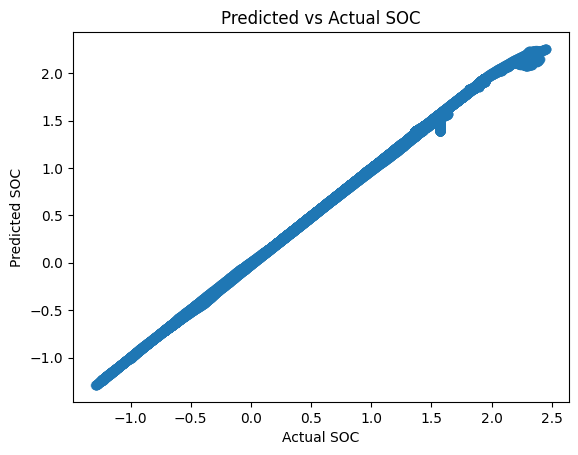

In [53]:
plt.figure()
plt.scatter(all_targets, all_preds, alpha=0.5)
plt.xlabel("Actual SOC")
plt.ylabel("Predicted SOC")
plt.title("Predicted vs Actual SOC")
plt.show()


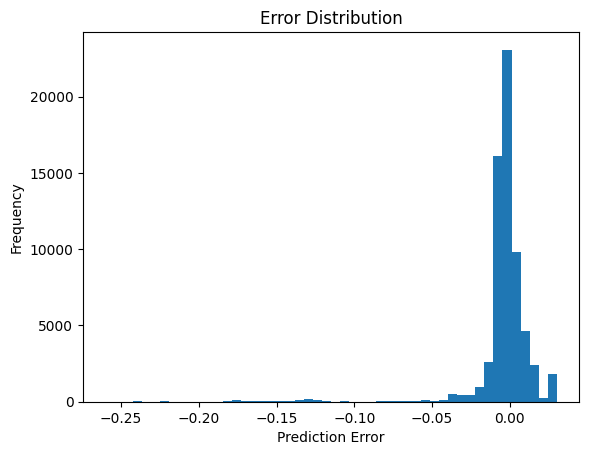

In [54]:
errors = all_preds - all_targets

plt.figure()
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()


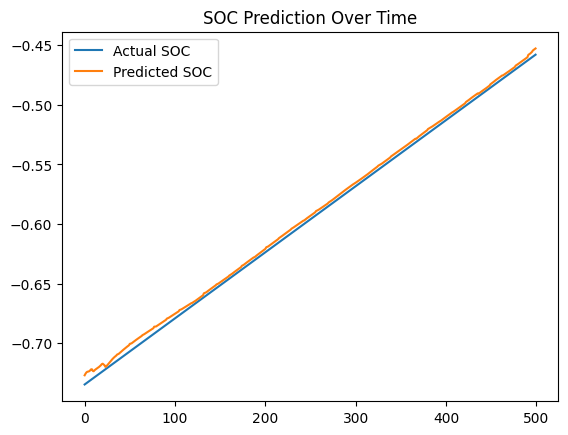

In [55]:
plt.figure()
plt.plot(all_targets[:500], label="Actual SOC")
plt.plot(all_preds[:500], label="Predicted SOC")
plt.legend()
plt.title("SOC Prediction Over Time")
plt.show()


In [56]:
torch.save(model.state_dict(), "battery_transformer_soc_model.pth")
print("Model saved successfully")


Model saved successfully
